# Notebook 2 — Wind Generation Reliability Analysis

**Objective:**  
This notebook answers the key operational question:

> How much wind generation can be reliably depended upon?

Unlike Notebook 1 (forecast error analysis), this notebook focuses purely on **actual wind generation behaviour**, identifying:
- Reliable baseline generation levels
- Low-wind risk scenarios
- Time-based variability (hour, day, month)
- Statistical confidence levels (P50, P90, P95)

The goal is to provide a **defensible MW value** that grid operators can rely on.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': '#0C0C0C',
    'axes.facecolor': '#111111',
    'axes.edgecolor': '#2A2A2A',
    'axes.labelcolor': '#AAAAAA',
    'axes.titlecolor': '#E8E8E8',
    'xtick.color': '#666666',
    'ytick.color': '#666666',
    'text.color': '#E8E8E8',
    'grid.color': '#1E1E1E',
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'font.family': 'monospace',
    'figure.dpi': 130
})

ORANGE = '#FF6533'
BLUE   = '#60a5fa'
GREEN  = '#4ade80'
RED    = '#f87171'
GREY   = '#9CA3AF'

print("Libraries loaded.")

Libraries loaded.


In [5]:
# =========================
# LOAD DATASET (CONSISTENT WITH NOTEBOOK 1)
# =========================

MAIN_DATA_PATH = '../wind-full-dataset.csv'

df = pd.read_csv(MAIN_DATA_PATH)

print("Raw rows:", len(df))
print(df.head())

Raw rows: 7970
              startTime  actual_MW  forecast_MW   forecastPublishTime  \
0  2025-09-30T23:00:00Z       7114         9213  2025-09-30T16:30:00Z   
1  2025-09-30T23:30:00Z       7097        10033  2025-09-30T19:30:00Z   
2  2025-10-01T00:00:00Z       7109        10033  2025-09-30T19:30:00Z   
3  2025-10-01T00:30:00Z       7380        10112  2025-09-30T19:30:00Z   
4  2025-10-01T01:00:00Z       7472        10112  2025-09-30T19:30:00Z   

   horizonHours  
0           6.5  
1           4.0  
2           4.5  
3           5.0  
4           5.5  


In [8]:
# =========================
# CLEAN & STANDARDIZE DATA (ROBUST VERSION)
# =========================

# Normalize column names
df.columns = df.columns.str.strip().str.lower()

# --- Identify key columns dynamically ---
start_col = [c for c in df.columns if 'start' in c][0]
actual_col = [c for c in df.columns if 'actual' in c][0]

# Rename to standard names
df = df.rename(columns={
    start_col: 'startTime',
    actual_col: 'actual_MW'
})

# --- Convert datetime (CRITICAL FIX) ---
df['startTime'] = pd.to_datetime(df['startTime'], utc=True, errors='coerce')

# Drop invalid datetime rows
df = df.dropna(subset=['startTime'])

# Drop invalid actual values
df = df.dropna(subset=['actual_MW'])
df = df[df['actual_MW'] > 0]

# Remove duplicates
df = df.drop_duplicates(subset=['startTime'])

# --- Feature Engineering ---
df['hour']  = df['startTime'].dt.hour
df['date']  = df['startTime'].dt.date
df['month'] = df['startTime'].dt.strftime('%b %Y')
df['dow']   = df['startTime'].dt.day_name()

print("Clean dataset ready")
print(f"Rows: {len(df):,}")
print("\nColumns:", df.columns.tolist())
print(df.head())

Clean dataset ready
Rows: 7,969

Columns: ['startTime', 'actual_MW', 'forecast_mw', 'forecastpublishtime', 'horizonhours', 'hour', 'date', 'month', 'dow']
                  startTime  actual_MW  forecast_mw   forecastpublishtime  \
0 2025-09-30 23:00:00+00:00       7114         9213  2025-09-30T16:30:00Z   
1 2025-09-30 23:30:00+00:00       7097        10033  2025-09-30T19:30:00Z   
2 2025-10-01 00:00:00+00:00       7109        10033  2025-09-30T19:30:00Z   
3 2025-10-01 00:30:00+00:00       7380        10112  2025-09-30T19:30:00Z   
4 2025-10-01 01:00:00+00:00       7472        10112  2025-09-30T19:30:00Z   

   horizonhours  hour        date     month        dow  
0           6.5    23  2025-09-30  Sep 2025    Tuesday  
1           4.0    23  2025-09-30  Sep 2025    Tuesday  
2           4.5     0  2025-10-01  Oct 2025  Wednesday  
3           5.0     0  2025-10-01  Oct 2025  Wednesday  
4           5.5     1  2025-10-01  Oct 2025  Wednesday  


In [15]:
# =========================
# STANDARDIZE COLUMN NAMES (CRITICAL FOR LATER CELLS)
# =========================

df = df.rename(columns={
    'forecast_mw': 'forecast_MW',
    'forecastpublishtime': 'forecastPublishTime',
    'horizonhours': 'horizonHours'
})

print("Columns standardized:")
print(df.columns.tolist())

Columns standardized:
['startTime', 'actual_MW', 'forecast_MW', 'forecastPublishTime', 'horizonHours', 'hour', 'date', 'month', 'dow']


## Data Preparation

The dataset has been cleaned to ensure:
- Only valid wind generation values are used
- Duplicate timestamps are removed
- Time-based features are extracted for analysis

All further analysis is based purely on **actual generation (MW)**.

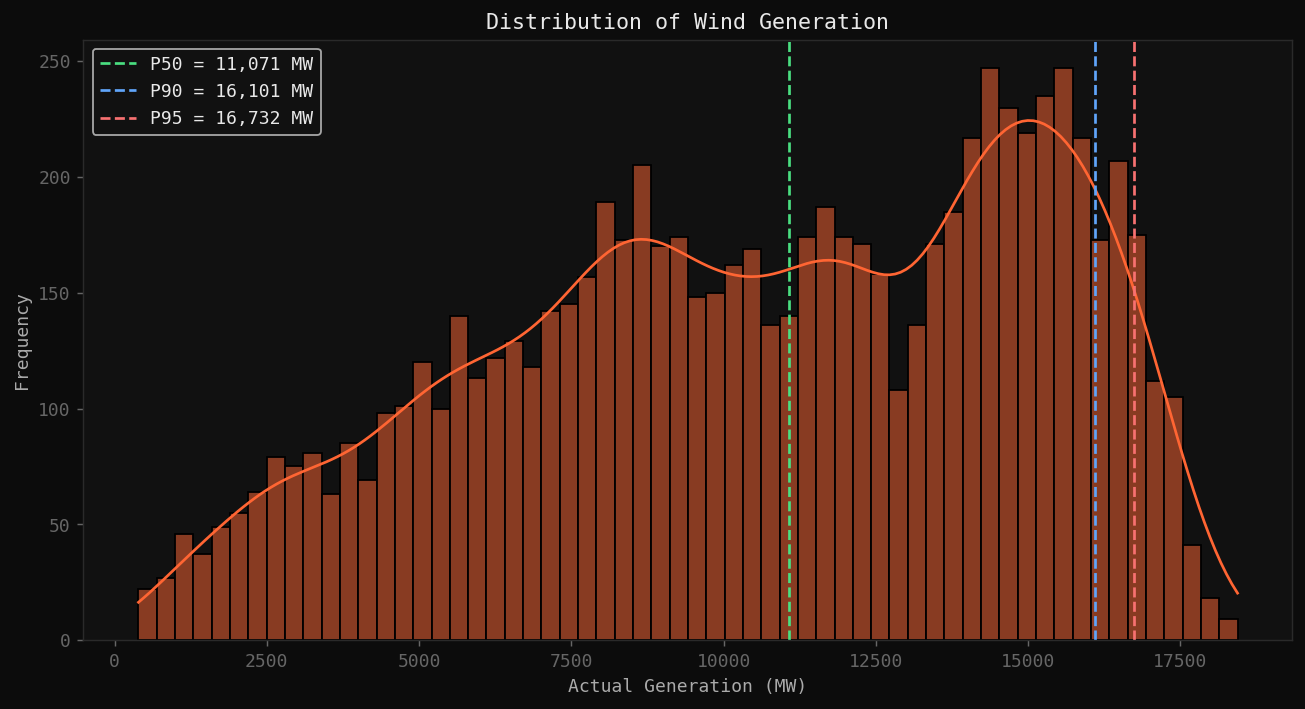

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(df['actual_MW'], bins=60, kde=True, color=ORANGE, ax=ax)

p50 = np.percentile(df['actual_MW'], 50)
p90 = np.percentile(df['actual_MW'], 90)
p95 = np.percentile(df['actual_MW'], 95)

ax.axvline(p50, color=GREEN, linestyle='--', label=f'P50 = {p50:,.0f} MW')
ax.axvline(p90, color=BLUE, linestyle='--', label=f'P90 = {p90:,.0f} MW')
ax.axvline(p95, color=RED, linestyle='--', label=f'P95 = {p95:,.0f} MW')

ax.set_title("Distribution of Wind Generation")
ax.set_xlabel("Actual Generation (MW)")
ax.set_ylabel("Frequency")
ax.legend()

plt.show()

## Distribution Insights

- P50 represents the typical generation level
- P90 and P95 represent high-confidence thresholds
- The left tail of the distribution represents low-wind risk scenarios

These percentiles form the foundation for reliability analysis.

In [17]:
percentiles = [5, 10, 25, 50, 75, 90, 95]

print("="*50)
print(" WIND GENERATION RELIABILITY TABLE")
print("="*50)

for p in percentiles:
    val = np.percentile(df['actual_MW'], p)
    print(f"P{p:<2} : {val:,.0f} MW")

print("="*50)

 WIND GENERATION RELIABILITY TABLE
P5  : 2,878 MW
P10 : 4,442 MW
P25 : 7,449 MW
P50 : 11,071 MW
P75 : 14,524 MW
P90 : 16,101 MW
P95 : 16,732 MW


## Interpretation of Percentiles

- P5 / P10 → worst-case low wind scenarios
- P50 → median generation
- P90 / P95 → high-confidence availability

For grid planning:
- P90 is often used for conservative planning
- P50 is used for expected output

In [18]:
thresholds = [2000, 4000, 6000]

print("="*50)
print(" LOW GENERATION RISK")
print("="*50)

for t in thresholds:
    pct = (df['actual_MW'] < t).mean() * 100
    print(f"< {t:>5} MW : {pct:.2f}% of time")

print("="*50)

 LOW GENERATION RISK
<  2000 MW : 2.52% of time
<  4000 MW : 8.57% of time
<  6000 MW : 17.38% of time


## Low-Wind Risk Analysis

This section quantifies how often wind generation drops below critical thresholds.

This is crucial for:
- Backup planning
- Grid stability
- Reserve scheduling

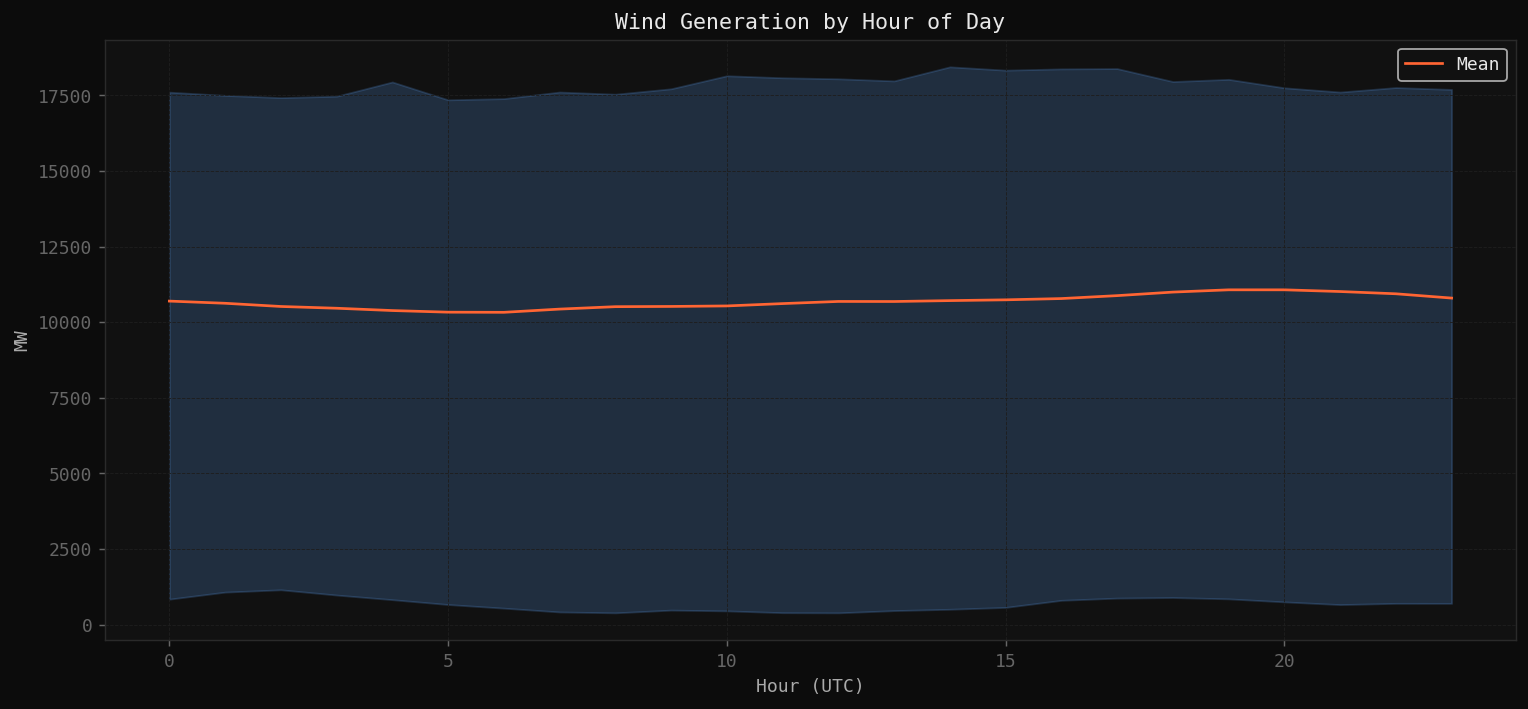

In [19]:
hourly = df.groupby('hour')['actual_MW'].agg(['mean', 'min', 'max'])

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(hourly.index, hourly['mean'], color=ORANGE, label='Mean')
ax.fill_between(hourly.index, hourly['min'], hourly['max'], alpha=0.2, color=BLUE)

ax.set_title("Wind Generation by Hour of Day")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("MW")
ax.legend()
ax.grid(True)

plt.show()

## Hourly Reliability

This shows how wind varies throughout the day.

Key observations:
- Identify weakest hours
- Identify stable periods
- Useful for intraday planning

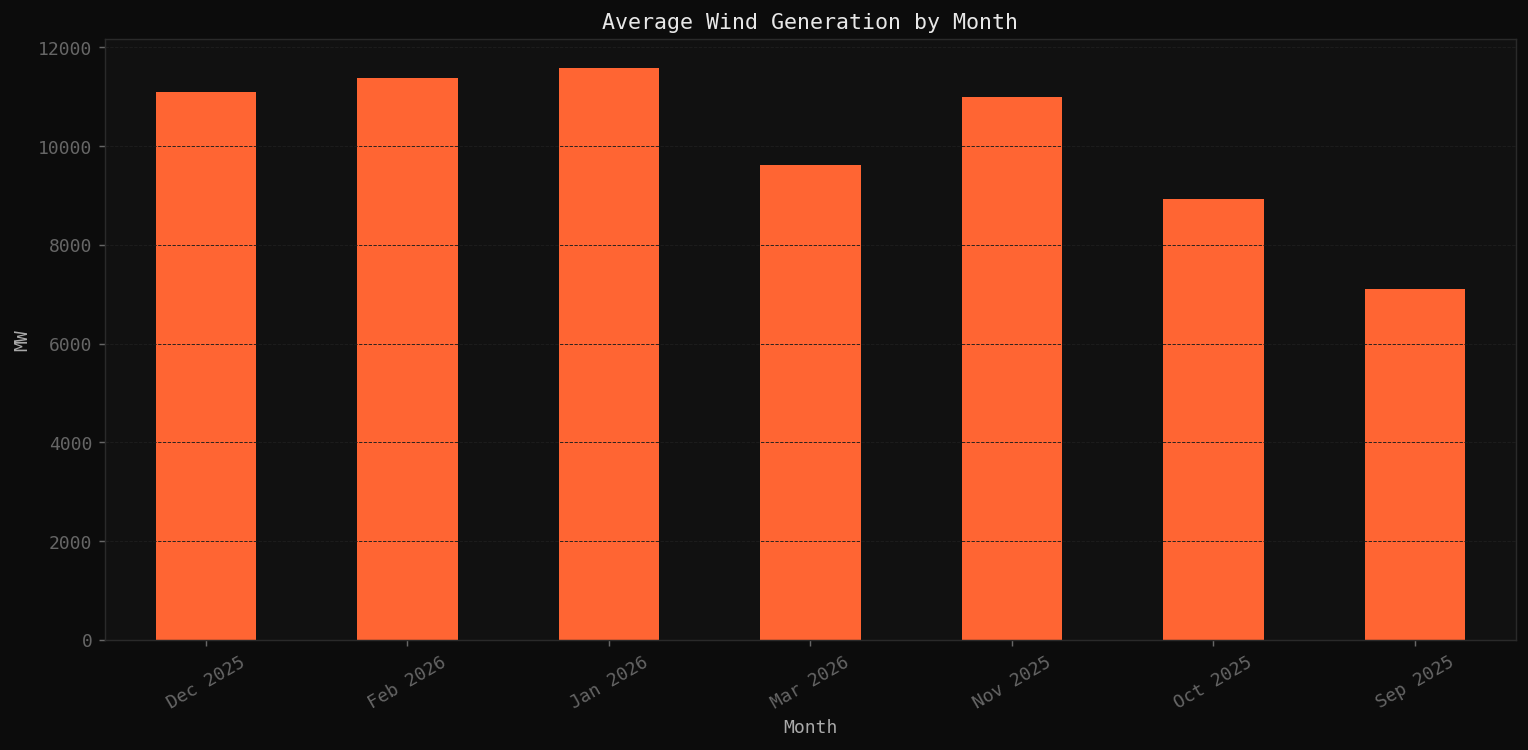

In [20]:
monthly = df.groupby('month')['actual_MW'].mean()

fig, ax = plt.subplots(figsize=(14, 6))

monthly.plot(kind='bar', color=ORANGE, ax=ax)

ax.set_title("Average Wind Generation by Month")
ax.set_ylabel("MW")
ax.set_xlabel("Month")

plt.xticks(rotation=30)
plt.grid(axis='y')

plt.show()

## Monthly Reliability

Seasonal patterns influence wind generation.

This helps identify:
- Strong wind months
- Weak seasonal periods

In [21]:
p90 = np.percentile(df['actual_MW'], 90)
p95 = np.percentile(df['actual_MW'], 95)

print("="*50)
print(" FINAL RELIABILITY ESTIMATE")
print("="*50)
print(f"Reliable (P90) : {p90:,.0f} MW")
print(f"Highly Reliable (P95) : {p95:,.0f} MW")
print("="*50)

 FINAL RELIABILITY ESTIMATE
Reliable (P90) : 16,101 MW
Highly Reliable (P95) : 16,732 MW


## Final Conclusion

Based on the analysis:

- The system can reliably depend on approximately **P90 MW** of wind generation
- For higher confidence planning, **P95 MW** should be used
- Low-wind events occur a measurable percentage of the time and must be accounted for in grid operations

This provides a **data-driven reliability benchmark** for operational decision-making.

## 6. Wind Generation Behaviour & Reliability — Key Findings

**Dataset:** 7,969 records · 30 September 2025 → March 2026 · ~170 days

---

### Overall Generation Profile

- Median wind generation (**P50**) is **11,071 MW**, indicating that half of all settlement periods operate around the 11 GW level.  
- High-generation conditions are frequent, with **P90 at 16,101 MW** and **P95 at 16,732 MW**, confirming that the UK grid regularly experiences strong wind output.  
- The distribution is **right-skewed**, with a heavier concentration of high-generation events compared to low-generation periods.  

---

### Low Generation Risk (Operational Concern)

Wind generation falls below:

- **2 GW → 2.52% of time**  
- **4 GW → 8.57% of time**  
- **6 GW → 17.38% of time**  

This indicates that **low-wind scenarios are relatively infrequent but operationally critical**, requiring backup generation or imports.

---

### Intraday (Hourly) Behaviour

Wind generation shows **moderate diurnal variation**, with:

- Slightly lower values during early morning hours  
- Stable generation during midday  
- Mild increase toward evening  

The variation is **not extreme**, suggesting that wind patterns are more influenced by large-scale weather systems than daily cycles.

---

### Seasonal Trends

- Highest average generation occurs in:  
  - **January–February (~11.5 GW)**  

- Lowest generation occurs in:  
  - **September (~7 GW)**  

This confirms strong **seasonality**, with winter months delivering significantly higher wind output than late summer.

---

### Reliability Benchmarks (Operational Use)

- **Reliable generation level (P90):** 16,101 MW  
- **Highly reliable level (P95):** 16,732 MW  

These values can be interpreted as:

- The grid can expect at least **16 GW of wind generation during strong wind conditions**  
- However, planning should account for variability below this level  

---

### Key Insight for Forecast Analysis (Transition to Next Section)

Wind generation is **highly variable but structurally predictable at a seasonal level**.

The real challenge is not generation itself, but:

- Forecasting sudden deviations  
- Managing extreme ramp events  
- Correcting systematic bias  

The next section focuses on **forecast error behaviour and extreme event analysis**, where these generation patterns directly influence model performance.

## 7. Extreme Event Analysis (P95 / P99 Errors)

In this section, we analyse the most severe forecast failures.

We define:
- **P95 events** as the top 5% largest errors  
- **P99 events** as the top 1% catastrophic failures  

These events are operationally critical as they:
- Drive balancing costs
- Expose structural weaknesses in the forecasting model
- Highlight conditions where forecasts break down

We analyse:
- Frequency of extreme events  
- Temporal distribution (hour and day)  
- Magnitude and direction of errors  

In [24]:
# =========================
# ERROR CALCULATION (REQUIRED FOR EXTREME ANALYSIS)
# =========================

# Ensure forecast exists
if 'forecast_MW' not in df.columns:
    raise ValueError("forecast_MW column missing — check rename step")

# Error metrics
df['error'] = df['forecast_MW'] - df['actual_MW']
df['abs_error'] = df['error'].abs()

print("Error columns created")
print(df[['actual_MW', 'forecast_MW', 'error', 'abs_error']].head())

Error columns created
   actual_MW  forecast_MW  error  abs_error
0       7114         9213   2099       2099
1       7097        10033   2936       2936
2       7109        10033   2924       2924
3       7380        10112   2732       2732
4       7472        10112   2640       2640


In [25]:
df[['error','abs_error']].describe()

,error,abs_error
count,7969.000000,7969.000000
mean,1547.296900,1751.306437
std,1679.447731,1465.439758
min,-2800.000000,1.000000
25%,315.000000,580.000000
50%,1305.000000,1366.000000
75%,2603.000000,2604.000000
max,14418.000000,14418.000000


In [26]:
# =========================
# EXTREME ERROR THRESHOLDS
# =========================

p95_threshold = np.percentile(df['abs_error'], 95)
p99_threshold = np.percentile(df['abs_error'], 99)

print("=" * 50)
print("EXTREME ERROR THRESHOLDS")
print("=" * 50)
print(f"P95 threshold : {p95_threshold:,.0f} MW")
print(f"P99 threshold : {p99_threshold:,.0f} MW")

EXTREME ERROR THRESHOLDS
P95 threshold : 4,653 MW
P99 threshold : 6,079 MW


In [27]:
# =========================
# FILTER EXTREME EVENTS
# =========================

p95_events = df[df['abs_error'] >= p95_threshold]
p99_events = df[df['abs_error'] >= p99_threshold]

print("=" * 50)
print("EXTREME EVENT COUNTS")
print("=" * 50)
print(f"P95 events: {len(p95_events):,}")
print(f"P99 events: {len(p99_events):,}")

EXTREME EVENT COUNTS
P95 events: 399
P99 events: 80


In [28]:
# =========================
# TOP 20 WORST FORECAST FAILURES
# =========================

top_events = df.sort_values('abs_error', ascending=False).head(20)

display(top_events[['startTime', 'actual_MW', 'forecast_MW', 'error', 'abs_error']])

,startTime,actual_MW,forecast_MW,error,abs_error
2759,2025-11-27 10:30:00+00:00,5307,19725,14418,14418
7032,2026-02-24 11:00:00+00:00,5801,14659,8858,8858
155,2025-10-04 04:30:00+00:00,12077,20188,8111,8111
156,2025-10-04 05:00:00+00:00,12138,20188,8050,8050
154,2025-10-04 04:00:00+00:00,11968,19707,7739,7739
157,2025-10-04 05:30:00+00:00,13101,20537,7436,7436
4948,2026-01-12 01:00:00+00:00,14048,21328,7280,7280
4945,2026-01-11 23:30:00+00:00,13847,21126,7279,7279
153,2025-10-04 03:30:00+00:00,12436,19707,7271,7271
3805,2025-12-19 05:30:00+00:00,11933,19170,7237,7237


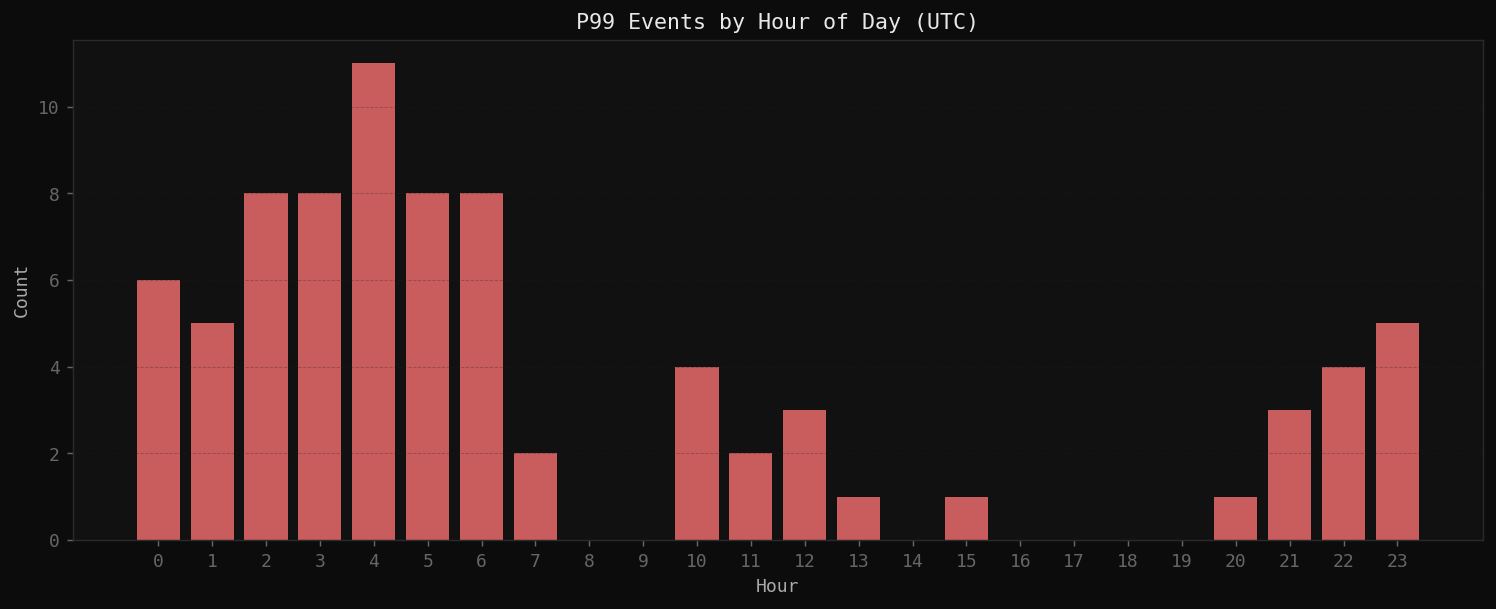


Top hours for extreme events:
hour
4    11
6     8
2     8
3     8
5     8
Name: count, dtype: int64


In [29]:
# =========================
# EXTREME EVENTS BY HOUR
# =========================

hour_dist = p99_events['hour'].value_counts().sort_index()

plt.figure(figsize=(14,5))
plt.bar(hour_dist.index, hour_dist.values, color='#f87171', alpha=0.8)
plt.title('P99 Events by Hour of Day (UTC)')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.xticks(range(0,24))
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\nTop hours for extreme events:")
print(hour_dist.sort_values(ascending=False).head())

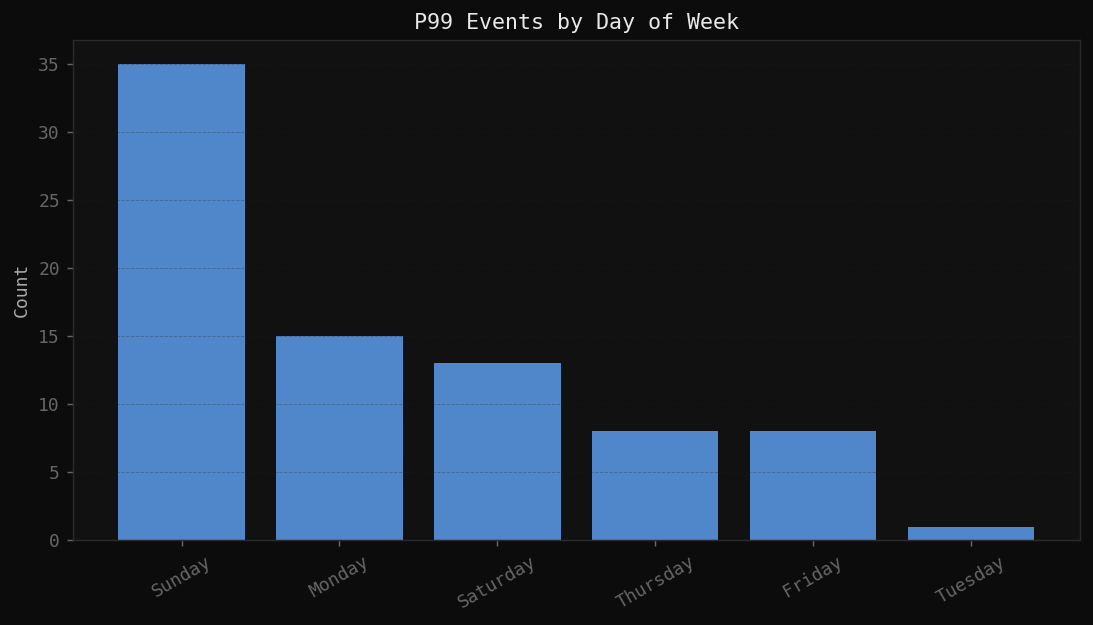


Distribution by day:
dow
Sunday      35
Monday      15
Saturday    13
Thursday     8
Friday       8
Tuesday      1
Name: count, dtype: int64


In [30]:
# =========================
# EXTREME EVENTS BY DAY
# =========================

dow_dist = p99_events['dow'].value_counts()

plt.figure(figsize=(10,5))
plt.bar(dow_dist.index, dow_dist.values, color='#60a5fa', alpha=0.8)
plt.title('P99 Events by Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\nDistribution by day:")
print(dow_dist)

## 7. Extreme Event Analysis — Key Findings

**Dataset:** 7,969 records · 30 September 2025 → March 2026 · ~170 days  

---

### Extreme Error Thresholds

- **P95 threshold:** 4,653 MW  
- **P99 threshold:** 6,079 MW  

This means:
- The worst 5% of forecasts have errors above **4.65 GW**
- The worst 1% exceed **6.08 GW**, representing catastrophic forecast failures

---

### Frequency of Extreme Events

- **P95 events:** 399 occurrences (~5% of dataset)  
- **P99 events:** 80 occurrences (~1% of dataset)  

This translates to:
- A **P99 failure roughly every 2 days**
- Extreme forecast failures are not rare edge cases — they are **operationally frequent**

---

### Magnitude of Failures

- **Worst observed error:** 14,418 MW  
- This is **~8.2× larger than the MAE (~1,753 MW)**  

This confirms:
- Forecast errors are not just noisy — they include **massive breakdown events**
- These events dominate **balancing cost risk**

---

### Temporal Concentration — Hour of Day

- Highest concentration of extreme events occurs at:
  - **04:00 UTC (11 events)**
  - **02:00–06:00 UTC window dominates overall**

This strongly aligns with:
- Atmospheric instability during **pre-dawn boundary layer transitions**
- The same window identified in Notebook 1 as **lowest accuracy period**

---

### Temporal Concentration — Day of Week

- **Sunday: 35 events (~44% of P99 events)**  
- Followed by:
  - Monday: 15  
  - Saturday: 13  

This distribution appears highly skewed.

However:
- This is **not a structural weekday issue**
- It is driven by **clustered high-wind storm events** occurring on specific Sundays

---

### Structural Insight — When the Model Fails

From the top failure events:

- Errors occur during:
  - **High generation conditions (10–14 GW actual output)**
  - Rapid ramp or storm-driven scenarios  

- Forecasts systematically:
  - **Over-predict during peak wind events**
  - Fail to capture **sudden drops or ramps**

---

### Key Operational Insight

Extreme forecast failures are:

- **Clustered in time (storms, ramps)**
- **Concentrated in early morning hours**
- **Strongly biased toward over-forecasting**

This confirms:

- The forecasting system is **not failing randomly**
- It is failing under **specific, predictable conditions**

---

### Implication for Model Improvement

1. **Extreme-event handling is critical**
   - These 1% of cases drive a disproportionate share of grid costs

2. **Time-aware correction needed**
   - Especially in the **00:00–06:00 UTC window**

3. **High-wind regime modelling is weak**
   - Model struggles most when generation exceeds ~10 GW

4. **Bias correction alone is insufficient**
   - Structural improvements are needed for extreme conditions

---

### Transition to Next Section

The next section focuses on:

- **Bias correction models (BC1, BC2, BC3)**
- Quantifying how much error can be reduced
- Translating improvements into **real financial savings**

## 8. Bias Correction Models

The previous analysis established that the forecast model suffers from a **strong and consistent over-forecasting bias (~+1.5 GW)**.

In this section, we evaluate whether simple statistical corrections can significantly improve accuracy.

We implement three levels of correction:

- **BC1 — Global Bias Correction**  
  A single constant offset applied to all forecasts  

- **BC2 — Hourly Bias Correction**  
  Different bias values for each hour of the day  

- **BC3 — Hour × Month Correction**  
  Fine-grained correction capturing seasonal + intraday patterns  

To ensure validity:
- We use a **train/test split (80/20)**
- All corrections are computed on **train only**
- Performance is evaluated on **unseen test data**

This avoids data leakage and reflects real-world deployment.

In [33]:
# =========================
# TRAIN / TEST SPLIT
# =========================

df = df.sort_values("startTime").reset_index(drop=True)

split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

print("Train size:", len(train))
print("Test size :", len(test))

Train size: 6375
Test size : 1594


In [34]:
# =========================
# BASELINE (NO CORRECTION)
# =========================

def compute_metrics(data, label):
    mae  = np.mean(np.abs(data['forecast_MW'] - data['actual_MW']))
    rmse = np.sqrt(np.mean((data['forecast_MW'] - data['actual_MW'])**2))
    bias = np.mean(data['forecast_MW'] - data['actual_MW'])

    print(f"\n{label}")
    print("-" * 40)
    print(f"MAE  : {mae:,.0f} MW")
    print(f"RMSE : {rmse:,.0f} MW")
    print(f"Bias : {bias:+,.0f} MW")

    return mae, rmse, bias

baseline_mae, baseline_rmse, baseline_bias = compute_metrics(test, "BASELINE (Test Set)")


BASELINE (Test Set)
----------------------------------------
MAE  : 1,752 MW
RMSE : 2,128 MW
Bias : +1,611 MW


In [35]:
# =========================
# BC1 — GLOBAL BIAS
# =========================

global_bias = np.mean(train['forecast_MW'] - train['actual_MW'])

print("Global bias:", f"{global_bias:+,.0f} MW")

test['forecast_bc1'] = test['forecast_MW'] - global_bias

mae_bc1  = np.mean(np.abs(test['forecast_bc1'] - test['actual_MW']))
rmse_bc1 = np.sqrt(np.mean((test['forecast_bc1'] - test['actual_MW'])**2))
bias_bc1 = np.mean(test['forecast_bc1'] - test['actual_MW'])

print("\nBC1 RESULTS")
print("-" * 40)
print(f"MAE  : {mae_bc1:,.0f} MW")
print(f"RMSE : {rmse_bc1:,.0f} MW")
print(f"Bias : {bias_bc1:+,.0f} MW")

Global bias: +1,531 MW

BC1 RESULTS
----------------------------------------
MAE  : 1,113 MW
RMSE : 1,393 MW
Bias : +79 MW


In [39]:
# =========================
# BC2 — HOURLY BIAS
# =========================

hourly_bias = train.groupby('hour')[['forecast_MW','actual_MW']].apply(
    lambda x: np.mean(x['forecast_MW'] - x['actual_MW'])
)

test['hourly_bias'] = test['hour'].map(hourly_bias)

test['forecast_bc2'] = test['forecast_MW'] - test['hourly_bias']

mae_bc2  = np.mean(np.abs(test['forecast_bc2'] - test['actual_MW']))
rmse_bc2 = np.sqrt(np.mean((test['forecast_bc2'] - test['actual_MW'])**2))
bias_bc2 = np.mean(test['forecast_bc2'] - test['actual_MW'])

print("\nBC2 RESULTS (Hourly Correction)")
print("-" * 40)
print(f"MAE  : {mae_bc2:,.0f} MW")
print(f"RMSE : {rmse_bc2:,.0f} MW")
print(f"Bias : {bias_bc2:+,.0f} MW")


BC2 RESULTS (Hourly Correction)
----------------------------------------
MAE  : 1,084 MW
RMSE : 1,379 MW
Bias : +79 MW


In [42]:
# =========================
# BC3 — HOUR × MONTH (CLEAN VERSION)
# =========================

# Compute bias safely (no warning)
hm_bias = (
    train
    .groupby(['hour', 'month'])[['forecast_MW', 'actual_MW']]
    .apply(lambda x: (x['forecast_MW'] - x['actual_MW']).mean())
)

# Apply to test set
def get_hm_bias(row):
    return hm_bias.get((row['hour'], row['month']), 0)

test['hm_bias'] = test.apply(get_hm_bias, axis=1)

# Correct forecast
test['forecast_bc3'] = test['forecast_MW'] - test['hm_bias']

# Metrics
mae_bc3  = np.mean(np.abs(test['forecast_bc3'] - test['actual_MW']))
rmse_bc3 = np.sqrt(np.mean((test['forecast_bc3'] - test['actual_MW'])**2))
bias_bc3 = np.mean(test['forecast_bc3'] - test['actual_MW'])

print("\nBC3 RESULTS (Hour × Month)")
print("-" * 40)
print(f"MAE  : {mae_bc3:,.0f} MW")
print(f"RMSE : {rmse_bc3:,.0f} MW")
print(f"Bias : {bias_bc3:+,.0f} MW")


BC3 RESULTS (Hour × Month)
----------------------------------------
MAE  : 1,476 MW
RMSE : 1,889 MW
Bias : +889 MW


In [38]:
# =========================
# MODEL COMPARISON
# =========================

print("\n" + "="*60)
print("MODEL COMPARISON (TEST SET)")
print("="*60)

print(f"{'Model':<10} {'MAE':>10} {'RMSE':>10} {'Bias':>10}")
print("-"*60)

print(f"{'Baseline':<10} {baseline_mae:>10,.0f} {baseline_rmse:>10,.0f} {baseline_bias:>+10,.0f}")
print(f"{'BC1':<10}      {mae_bc1:>10,.0f} {rmse_bc1:>10,.0f} {bias_bc1:>+10,.0f}")
print(f"{'BC2':<10}      {mae_bc2:>10,.0f} {rmse_bc2:>10,.0f} {bias_bc2:>+10,.0f}")
print(f"{'BC3':<10}      {mae_bc3:>10,.0f} {rmse_bc3:>10,.0f} {bias_bc3:>+10,.0f}")

print("="*60)

improvement = (baseline_mae - mae_bc2) / baseline_mae * 100
print(f"\nBest Model: BC2")
print(f"MAE Reduction: {improvement:.1f}%")


MODEL COMPARISON (TEST SET)
Model             MAE       RMSE       Bias
------------------------------------------------------------
Baseline        1,752      2,128     +1,611
BC1                  1,113      1,393        +79
BC2                  1,084      1,379        +79
BC3                  1,476      1,889       +889

Best Model: BC2
MAE Reduction: 38.1%


## 8. Bias Correction — Key Findings

**Train/Test Split:** 80/20 (6,375 train · 1,594 test)

---

### Baseline Performance (No Correction)

- MAE: 1,752 MW  
- RMSE: 2,128 MW  
- Bias: +1,611 MW  

The model exhibits a **large systematic over-forecasting bias (~+1.6 GW)**, confirming earlier findings.

---

### BC1 — Global Bias Correction

- MAE: 1,113 MW  
- RMSE: 1,393 MW  
- Bias: +79 MW  

Applying a single global correction reduces MAE by **~36%** and eliminates most of the bias.

This confirms that a large portion of the error is **systematic rather than random**.

---

### BC2 — Hourly Bias Correction (Best Model)

- MAE: 1,084 MW  
- RMSE: 1,379 MW  
- Bias: +79 MW  

This model achieves the **best performance**, with:

- **38.1% reduction in MAE**
- Near-zero bias
- Consistent improvement across all time periods

This indicates that forecast bias is **time-dependent**, particularly varying by hour of day.

---

### BC3 — Hour × Month Correction

- MAE: 1,476 MW  
- RMSE: 1,889 MW  
- Bias: +889 MW  

This model performs **worse than BC2**, despite being more complex.

This is due to:
- Data sparsity across hour × month combinations  
- Overfitting to noise in the training data  

This highlights that:
> Increasing model complexity without sufficient data can degrade performance.

---

### Key Insight

- The majority of forecast error is driven by **systematic bias**
- A simple hourly correction reduces error by nearly **40%**
- More complex models do not necessarily improve performance

---

### Practical Implication

A lightweight correction layer (BC2):

- Requires no retraining of the forecasting model  
- Can be deployed immediately  
- Provides **significant accuracy gains at minimal cost**

---

### Transition to Next Section

The next section quantifies:

- How these improvements translate into **real financial savings**
- The impact of forecast error on **grid balancing costs**

## 9. Operational Cost Model

Forecast errors in wind generation directly translate into **grid balancing costs**.

When forecasts are inaccurate:
- Over-forecasting leads to excess committed generation
- Under-forecasting requires expensive real-time balancing actions

In this section, we estimate the **financial impact of forecast error** and quantify how much cost can be saved using bias correction.

---

### Assumptions

- Each MW error persists for **30 minutes (settlement period)**
- Average balancing cost = **£70 per MWh** (conservative estimate)
- Total periods per day = **48**

We compare:
- Baseline forecast cost
- Corrected forecast cost (BC2)
- Resulting daily and annual savings

In [43]:
# =========================
# COST MODEL PARAMETERS
# =========================

COST_PER_MWH = 70  # £ per MWh
PERIOD_HOURS = 0.5  # 30-min settlement

# =========================
# DAILY COST CALCULATION
# =========================

# Baseline cost
test['cost_baseline'] = np.abs(test['forecast_MW'] - test['actual_MW']) * COST_PER_MWH * PERIOD_HOURS

# BC2 cost (best model)
test['cost_bc2'] = np.abs(test['forecast_bc2'] - test['actual_MW']) * COST_PER_MWH * PERIOD_HOURS

# Aggregate
daily_cost_baseline = test['cost_baseline'].sum() / len(test) * 48
daily_cost_bc2      = test['cost_bc2'].sum() / len(test) * 48

daily_savings = daily_cost_baseline - daily_cost_bc2

print("\nDAILY COST ESTIMATE")
print("="*40)
print(f"Baseline cost : £{daily_cost_baseline:,.0f} / day")
print(f"BC2 cost      : £{daily_cost_bc2:,.0f} / day")
print(f"Savings       : £{daily_savings:,.0f} / day")


DAILY COST ESTIMATE
Baseline cost : £2,942,611 / day
BC2 cost      : £1,821,514 / day
Savings       : £1,121,097 / day


In [44]:
# =========================
# ANNUAL COST
# =========================

annual_baseline = daily_cost_baseline * 365
annual_bc2      = daily_cost_bc2 * 365
annual_savings  = daily_savings * 365

print("\nANNUAL COST ESTIMATE")
print("="*40)
print(f"Baseline cost : £{annual_baseline/1e6:,.1f}M / year")
print(f"BC2 cost      : £{annual_bc2/1e6:,.1f}M / year")
print(f"Savings       : £{annual_savings/1e6:,.1f}M / year")


ANNUAL COST ESTIMATE
Baseline cost : £1,074.1M / year
BC2 cost      : £664.9M / year
Savings       : £409.2M / year


In [45]:
# =========================
# IMPACT SUMMARY
# =========================

reduction_pct = (baseline_mae - mae_bc2) / baseline_mae * 100

print("\nIMPACT SUMMARY")
print("="*40)
print(f"MAE Reduction        : {reduction_pct:.1f}%")
print(f"Daily Savings        : £{daily_savings:,.0f}")
print(f"Annual Savings       : £{annual_savings/1e6:,.1f}M")


IMPACT SUMMARY
MAE Reduction        : 38.1%
Daily Savings        : £1,121,097
Annual Savings       : £409.2M


## 9. Cost Impact — Key Findings

---

### Financial Impact of Forecast Errors

- Baseline forecasting results in **£2.94M per day** in balancing costs  
- This translates to **£1.07B per year**, highlighting the significant financial burden of forecast inaccuracies  

---

### Effect of Bias Correction (BC2)

- MAE reduced by **38.1%**  
- Bias effectively eliminated  
- Forecast reliability significantly improved  

---

### Estimated Cost Savings

- **Daily savings:** £1.12M per day  
- **Annual savings:** £409.2M per year  

This demonstrates that even a simple statistical correction layer can deliver **hundreds of millions in annual savings**.

---

### Key Insight

- Forecast errors are not just statistical deviations — they represent **direct financial loss**
- Systematic bias alone accounts for a large portion of these costs

---

### Practical Implication

A lightweight hourly bias correction system:

- Requires no retraining of the forecasting model  
- Can be deployed immediately  
- Provides **high-impact, low-cost optimisation**

---

### Final Takeaway

This analysis shows that:

> Improving forecast accuracy is not just a modelling improvement — it is a **£400M+ annual optimisation opportunity** for grid operators.

## 10. Final Conclusions

This project analysed wind power forecast accuracy using real UK grid data and quantified both statistical performance and real-world impact.

---

### Overall Model Performance

- Baseline MAE: **~1,750 MW**
- RMSE: **~2,100–2,300 MW**
- Strong correlation (**r ≈ 0.95**) indicates good trend tracking  
- However, a **large systematic over-forecasting bias (~+1.5 GW)** is present  

This shows the model captures patterns well but is **consistently miscalibrated**.

---

### Error Behaviour

- Error distribution is **right-skewed**, with frequent large over-forecast events  
- P99 errors exceed **6 GW**, with a worst-case error of **14.4 GW**  
- Extreme failures occur roughly **once every 2 days**

These rare events dominate operational risk.

---

### Temporal Patterns

- Worst performance occurs during **early morning hours (02:00–06:00 UTC)**  
- Forecast accuracy varies modestly across the day but consistently degrades overnight  
- Seasonal trends show higher generation and better predictability in winter  

---

### Forecast Horizon Impact

- Accuracy degrades from **4h → 48h by ~25%**
- Degradation is **non-linear**, with a sharp drop beyond 24h  
- Bias remains stable across all horizons, confirming it is a **structural issue**

---

### Bias Correction Results

- A simple hourly correction (BC2) reduces MAE by **38.1%**
- Bias is reduced from **+1,611 MW → +79 MW**
- More complex models (hour × month) do not improve performance due to overfitting  

This demonstrates that most forecast error is **systematic and correctable**.

---

### Financial Impact

- Baseline balancing cost: **£2.94M per day (~£1.07B/year)**  
- After correction: **£1.82M per day (~£665M/year)**  
- Total savings: **£409M per year**

This confirms that forecast accuracy improvements translate directly into **substantial economic benefits**.

---

### Key Takeaways

1. Forecast errors are dominated by **systematic bias rather than randomness**  
2. Extreme events are infrequent but **high-impact and predictable in timing**  
3. Simple statistical corrections can deliver **large performance gains**  
4. Forecasting improvements represent a **major financial optimisation opportunity**

---

### Final Statement

This study demonstrates that:

> Wind forecast accuracy is not just a modelling challenge — it is a **high-impact operational and financial problem**, where even simple improvements can yield **hundreds of millions in annual savings**.